In [3]:
# ================================================
'''
2. 다중 클래스 분류(Multi-class Classification) 실습
- 3개 클래스 분류
- 학습 결과 저장
- 저장된 모델/스케일러/학습 이력 불러오기
- 신규 데이터 예측
- 학습결과 및 예측결과 시각화
'''
# ================================================

'\n2. 다중 클래스 분류(Multi-class Classification) 실습\n- 3개 클래스 분류\n- 학습 결과 저장\n- 저장된 모델/스케일러/학습 이력 불러오기\n- 신규 데이터 예측\n- 학습결과 및 예측결과 시각화\n'

## x 입력값
| Feature                      | 설명         |
| ---------------------------- | ---------- |
| alcohol                      | 알코올 농도     |
| malic_acid                   | 말산         |
| ash                          | 회분         |
| alcalinity_of_ash            | 회분 알칼리도    |
| magnesium                    | 마그네슘       |
| total_phenols                | 총 페놀       |
| flavanoids                   | 플라보노이드     |
| nonflavanoid_phenols         | 비플라보노이드 페놀 |
| proanthocyanins              | 프로안토시아닌    |
| color_intensity              | 색 강도       |
| hue                          | 색조         |
| od280/od315_of_diluted_wines | 단백질 흡광도    |
| proline                      | 프롤린 (아미노산) |

## 타겟
* Class 0 → 와인 종류 A
* Class 1 → 와인 종류 B
* Class 2 → 와인 종류 C

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine               # 와인 데이터 셋 읽어오기
import joblib                                         # 파이썬 객체 저장을 위한 joblib

import tensorflow as tf                               # 딥러닝 프레임워크

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout               # 레이어 구성, 드롭아웃 적용 위한 라이브러리
from tensorflow.keras.callbacks import EarlyStopping             # 학습 조기종료 콜백 라이브러리
from tensorflow.keras.utils import to_categorical      

np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# ================================================
# 1. 데이터 읽어오기
# ================================================

data = load_wine()
X = data.data      # 입력 x data
y = data.target    # 타겟 레이블 y 데이터 (예측하고자 하는 데이터의 정답 레이블)

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)   # 데이터 확인을 위해 데이터프레임으로 변환

df['target'] = y 

print('전체 데이터 shape: ', df.shape)

전체 데이터 shape:  (178, 14)


In [8]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
# ================================================
# 2. 학습용/테스트용 데이터 분할  (학습데이터 80% / 테스트데이터 20%)
# ================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# ================================================
# 3. 스케일링
# ================================================
scaler = StandardScaler()                         # 스케일러 객체 생성
X_train_scaled = scaler.fit_transform(X_train)    # 학습 데이터 기준으로 평균과 표준편차를 학습하고 반환
X_test_scaled = scaler.transform(X_test)          # 테스트 데이터는 학습 데이터 기준으로 반환

In [12]:
# ================================================
# 4. one-hot 인코드 수행
# ================================================
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [14]:
# ================================================
# 5. 모델 정의
# ================================================
model = Sequential()               # 순차형 신경망 모델 생성

# 첫 번째 은닉층 추가
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))        # 과적합 방지를 위해 드롭아웃 20% 적용

# 두 번째 은닉층 추가
model.add(Dense(32, activation='relu'))

# 출력층 추가
model.add(Dense(3, activation='softmax'))        # 출력층은 클래스 3개, 활성화 함수는 softmax 사용

In [15]:
# ================================================
# 6. 모델 컴파일 설정
# ================================================

model.compile(
    optimizer='adam',             # 학습은 adam 적용
    loss='categorical_crossentropy',   # 손실함수는 categorical_crossentropy 적용
    metrics=['accuracy']          # 평가지표는 accuracy 사용
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',       # val_loss 값이 더이상 줄어들지 않고 계속 같은 값이 나온다면 학습 종료
    patience=10,
    restore_best_weights=True
)

In [16]:
# ================================================
# 7. 모델 학습
# ================================================
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.4425 - loss: 1.0697 - val_accuracy: 0.7586 - val_loss: 0.7999
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7345 - loss: 0.8164 - val_accuracy: 0.8276 - val_loss: 0.6447
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7965 - loss: 0.6759 - val_accuracy: 0.9310 - val_loss: 0.5280
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8673 - loss: 0.5369 - val_accuracy: 0.9655 - val_loss: 0.4358
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9115 - loss: 0.4501 - val_accuracy: 0.9655 - val_loss: 0.3603
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9115 - loss: 0.3978 - val_accuracy: 0.9655 - val_loss: 0.2962
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9292 - loss: 0.3336 - val_accuracy: 0.9655 - val_loss: 0.2434
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9558 - loss: 0.2705 - val_accuracy: 0.9655 - val_loss:

In [17]:
# ================================================
# 8. 모델 평가
# ================================================
# 테스트 데이터(20%)에 대해 손실과 정확도를 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 가장 확률이 높은 클래스를 선택
y_pred = np.argmax(y_prob, axis=1)  

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도: ', acc)
print('confusion matirix: \n', cm)
print('분류 리포트: \n', classification_report(y_test, y_pred))


테스트 손실:  0.0518336147069931
테스트 정확도:  0.9444444179534912
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
정확도:  0.9444444444444444
confusion matirix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  2  8]]
분류 리포트: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [18]:
# ================================================
# 9. 학습결과 저장
# ================================================

# 모델을 파일로 저장
model.save('./model/MultiClass_Classification.h5')   # 또는 Binary_Classification.keras

# 스케일러를 파일로 저장
joblib.dump(scaler, './model/MultiClass_Classification.pkl')

# 학습이력을 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv('./model/MultiClass_Classification.csv', index=False)

print("멀티 분류 모델, 스케일러, 학습이력 저장 완료")

멀티 분류 모델, 스케일러, 학습이력 저장 완료


In [19]:
# ================================================
# 10. 저장된 결과 읽어오기
# ================================================
# 저장된 모델을 다시 읽어오기
loaded_model = tf.keras.models.load_model('./model/MultiClass_Classification.h5')

# 저장된 스케일러를 다시 읽어오기
loaded_scaler = joblib.load('./model/MultiClass_Classification.pkl')

In [29]:
# ================================================
# 11. 신규 데이터 예측
# ================================================

# 학습하지 않은 테스터데이터 중 10개를 신규 데이터로 예측 수행
new_data = X_test[:10]

# 신규 데이터 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 확률이 가장 큰 클래스 선택
new_pred = np.argmax(new_prob, axis=1)

# 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i]}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1번 샘플 - 예측확률: [9.9999976e-01 1.2533459e-07 8.2652193e-08], 예측클래스: 0
2번 샘플 - 예측확률: [0.00163908 0.59093213 0.4074288 ], 예측클래스: 1
3번 샘플 - 예측확률: [9.9998987e-01 8.3922923e-06 1.7983772e-06], 예측클래스: 0
4번 샘플 - 예측확률: [4.7145605e-02 9.5284528e-01 9.0602634e-06], 예측클래스: 1
5번 샘플 - 예측확률: [1.0575671e-03 9.9851435e-01 4.2802535e-04], 예측클래스: 1
6번 샘플 - 예측확률: [9.9999893e-01 6.5188186e-07 4.3805943e-07], 예측클래스: 0
7번 샘플 - 예측확률: [9.9999726e-01 9.0872766e-07 1.8119717e-06], 예측클래스: 0
8번 샘플 - 예측확률: [7.8160716e-03 9.9218220e-01 1.6618726e-06], 예측클래스: 1
9번 샘플 - 예측확률: [0.0014353  0.99709797 0.00146679], 예측클래스: 1
10번 샘플 - 예측확률: [1.7388160e-05 6.9780392e-05 9.9991286e-01], 예측클래스: 2


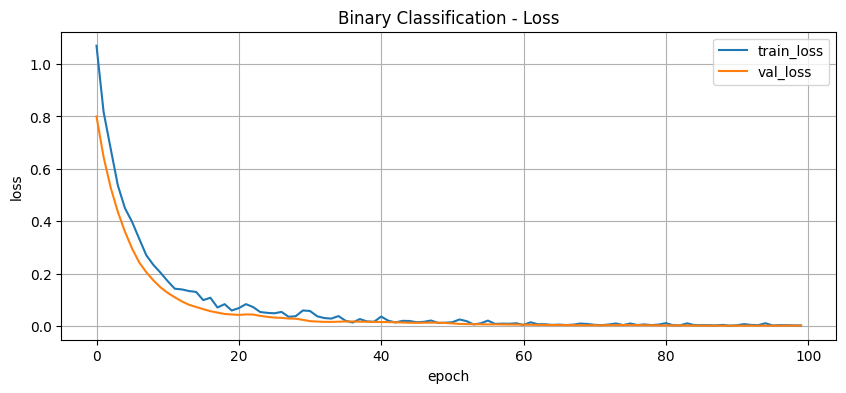

In [30]:
# ================================================
# 12. 시각화 결과 확인
# ================================================

# 학습, loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary Classification - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)  # 그래프 격자 표시
plt.show()

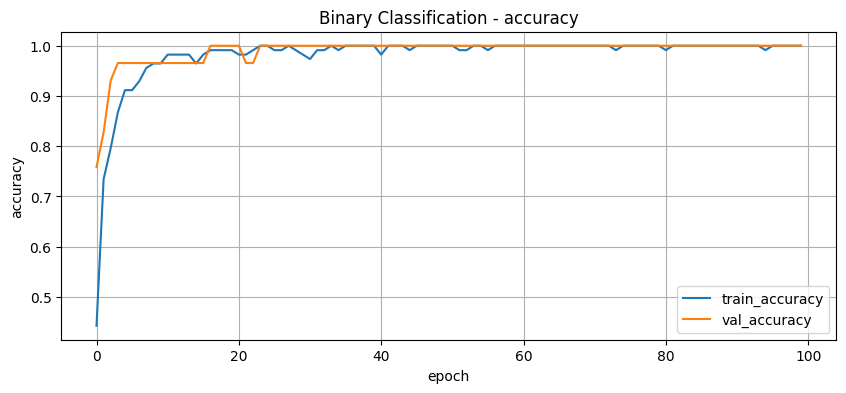

In [31]:
# 학습, 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary Classification - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)  # 그래프 격자 표시
plt.show()

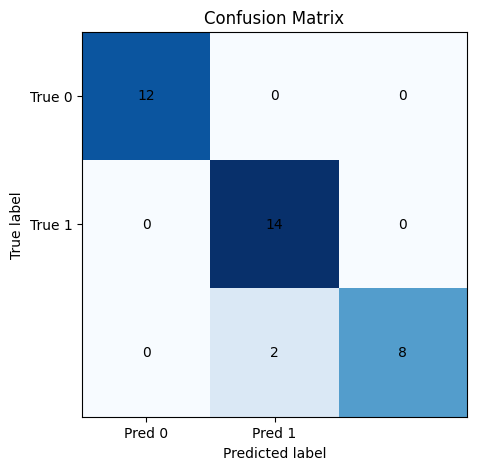

In [32]:
# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# cm 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

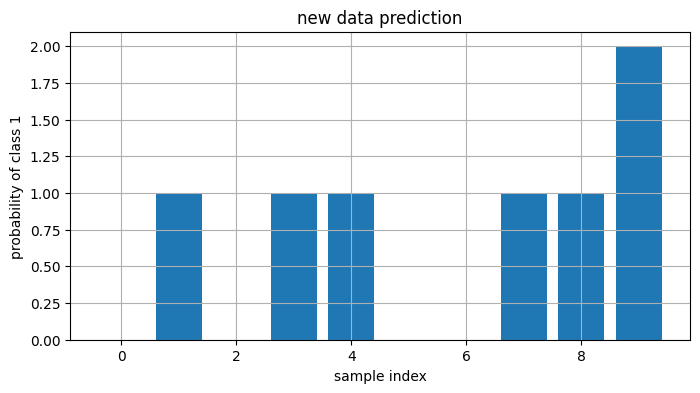

In [33]:
# 신규 데이터 예측 결과 시각화

plt.figure(figsize=(8,4))
plt.bar(range(len(new_pred)), new_pred)

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()